# AI Interior Design Visualizer

Tagline: Redecorate your room before buying a single thing.

This notebook is a prototype for a browser-based room redesign workflow. It demonstrates three separate pieces of logic: segmentation for room regions, palette extraction for color suggestions, and preset-based furniture styling for before/after previews.

Important status notes:

1. Segmentation is prototype-level. It can use SAM if a checkpoint is available, otherwise it falls back to deterministic region masks for the demo image.
2. Palette recommendation is working. It uses OpenCV k-means to extract dominant colors from the image.
3. Furniture replacement is simulated, not generative. The notebook applies color/theme presets to masked furniture regions; it does not synthesize new furniture with a diffusion or inpainting model.



In [11]:
from __future__ import annotations

import hashlib
import importlib
import json
import subprocess
import sys
import urllib.request
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np


def ensure_package(import_name: str, pip_spec: str):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f'Installing {pip_spec} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_spec])
        return importlib.import_module(import_name)


try:
    torch = ensure_package('torch', 'torch')
except Exception:
    torch = None

try:
    Flask_module = ensure_package('flask', 'flask')
    Flask = Flask_module.Flask
    jsonify = Flask_module.jsonify
    request = Flask_module.request
except Exception:
    Flask = None
    jsonify = None
    request = None

try:
    segment_anything = ensure_package('segment_anything', 'git+https://github.com/facebookresearch/segment-anything.git')
    SamPredictor = segment_anything.SamPredictor
    sam_model_registry = segment_anything.sam_model_registry
except Exception:
    SamPredictor = None
    sam_model_registry = None


PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'README.md').exists()),
    Path.cwd(),
)
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAM_CHECKPOINT = NOTEBOOK_DIR / 'checkpoints' / 'sam_vit_b_01ec64.pth'
SAM_CHECKPOINT_URL = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
ROOM_IMAGE_CANDIDATES = [
    NOTEBOOK_DIR / 'test2.png',
    PROJECT_ROOT / 'data' / 'room.jpg',
    PROJECT_ROOT / 'data' / 'room.png',
    PROJECT_ROOT / 'frontend' / 'public' / 'room.jpg',
    PROJECT_ROOT / 'frontend' / 'public' / 'room.png',
    PROJECT_ROOT / 'assets' / 'room.jpg',
    PROJECT_ROOT / 'assets' / 'room.png',
]

STYLE_THEMES = {
    'scandinavian': {
        'wall': [244, 239, 232],
        'sofa': [233, 226, 218],
        'wood': [199, 175, 145],
        'accent': [165, 191, 183],
    },
    'modern_luxe': {
        'wall': [226, 220, 214],
        'sofa': [58, 62, 70],
        'wood': [139, 104, 84],
        'accent': [192, 153, 105],
    },
    'japandi': {
        'wall': [238, 232, 222],
        'sofa': [208, 198, 184],
        'wood': [176, 143, 108],
        'accent': [124, 145, 133],
    },
    'industrial': {
        'wall': [225, 225, 226],
        'sofa': [94, 97, 104],
        'wood': [112, 93, 81],
        'accent': [173, 124, 98],
    },
}


def ensure_checkpoint(url: str, path: Path) -> Path:
    if path.exists() and path.stat().st_size > 0:
        return path
    print(f'Downloading SAM checkpoint to {path} ...')
    path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, path)
    return path


if torch is not None and SamPredictor is not None and sam_model_registry is not None:
    try:
        SAM_CHECKPOINT = ensure_checkpoint(SAM_CHECKPOINT_URL, SAM_CHECKPOINT)
    except Exception as exc:
        print(f'Could not download SAM checkpoint: {exc}')


def rgb_to_hex(rgb: np.ndarray | list[int] | tuple[int, int, int]) -> str:
    red, green, blue = [int(value) for value in rgb]
    return f'#{red:02x}{green:02x}{blue:02x}'


def show_side_by_side(left: np.ndarray, right: np.ndarray, left_title: str, right_title: str, figsize=(14, 6)):
    figure, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(left)
    axes[0].set_title(left_title)
    axes[0].axis('off')
    axes[1].imshow(right)
    axes[1].set_title(right_title)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def build_rect_mask(shape: tuple[int, int], rectangles: list[tuple[int, int, int, int]]) -> np.ndarray:
    mask = np.zeros(shape, dtype=bool)
    for x1, y1, x2, y2 in rectangles:
        mask[y1:y2, x1:x2] = True
    return mask


def overlay_mask(image_rgb: np.ndarray, mask: np.ndarray, color: tuple[int, int, int], alpha: float = 0.55) -> np.ndarray:
    overlay = image_rgb.copy().astype(np.float32)
    color_array = np.array(color, dtype=np.float32)
    overlay[mask] = overlay[mask] * (1.0 - alpha) + color_array * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)


def mask_to_svg_layers(mask: np.ndarray, layer_name: str, stroke: str, fill: str, min_area: float = 80.0) -> list[dict[str, Any]]:
    mask_uint8 = (mask.astype(np.uint8)) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    layers: list[dict[str, Any]] = []
    for index, contour in enumerate(contours):
        area = float(cv2.contourArea(contour))
        if area < min_area:
            continue
        epsilon = max(2.0, 0.01 * cv2.arcLength(contour, True))
        approximation = cv2.approxPolyDP(contour, epsilon, True)
        points = approximation.reshape(-1, 2)
        if len(points) == 0:
            continue
        path_parts = [f'M {int(points[0][0])} {int(points[0][1])}']
        for x_value, y_value in points[1:]:
            path_parts.append(f'L {int(x_value)} {int(y_value)}')
        path_parts.append('Z')
        svg_path = ' '.join(path_parts)
        x, y, width, height = cv2.boundingRect(approximation)
        layers.append(
            {
                'id': f'{layer_name}-{index + 1}',
                'svgPath': svg_path,
                'polygon': points.tolist(),
                'bbox': {'x': int(x), 'y': int(y), 'width': int(width), 'height': int(height)},
                'area': area,
                'fabricPathConfig': {
                    'path': svg_path,
                    'fill': fill,
                    'stroke': stroke,
                    'strokeWidth': 2,
                    'strokeUniform': True,
                },
            }
        )
    return layers


def make_demo_room(width: int = 960, height: int = 640) -> tuple[np.ndarray, dict[str, Any]]:
    image = np.full((height, width, 3), (238, 232, 224), dtype=np.uint8)
    cv2.rectangle(image, (0, int(height * 0.58)), (width, height), (191, 168, 144), -1)
    cv2.rectangle(image, (65, 62), (330, 255), (228, 244, 250), -1)
    cv2.rectangle(image, (86, 84), (309, 234), (255, 255, 255), 6)
    cv2.rectangle(image, (170, 300), (680, 520), (80, 84, 92), -1)
    cv2.rectangle(image, (205, 330), (645, 500), (116, 120, 130), -1)
    cv2.rectangle(image, (500, 286), (710, 466), (235, 226, 212), -1)
    cv2.circle(image, (715, 248), 44, (214, 188, 150), -1)
    cv2.rectangle(image, (744, 140), (888, 520), (213, 203, 190), -1)
    cv2.rectangle(image, (735, 120), (900, 540), (194, 181, 164), 5)
    layout = {
        'wall': [(0, 0, width, int(height * 0.58))],
        'floor': [(0, int(height * 0.58), width, height)],
        'sofa': [(170, 300, 680, 520)],
        'table': [(500, 286, 710, 466)],
        'lamp': [(690, 160, 770, 330)],
        'plant': [(745, 140, 888, 520)],
    }
    return image, layout


def load_room_image() -> tuple[np.ndarray, str, dict[str, Any]]:
    for candidate in ROOM_IMAGE_CANDIDATES:
        if candidate.exists():
            image_bgr = cv2.imread(str(candidate), cv2.IMREAD_COLOR)
            if image_bgr is None:
                continue
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            return image_rgb, candidate.name, {}
    image_rgb, layout = make_demo_room()
    return image_rgb, 'synthetic_demo', layout


def try_build_sam_predictor(checkpoint_path: Path):
    if torch is None or SamPredictor is None or sam_model_registry is None:
        return None
    if not checkpoint_path.exists():
        return None
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    sam = sam_model_registry['vit_b'](checkpoint=str(checkpoint_path))
    sam.to(device=device)
    sam.eval()
    return SamPredictor(sam)


def build_reference_masks(image_shape: tuple[int, int], image_source: str, scene_layout: dict[str, Any]) -> dict[str, np.ndarray]:
    height, width = image_shape
    if image_source == 'synthetic_demo' and scene_layout:
        return {name: build_rect_mask((height, width), rectangles) for name, rectangles in scene_layout.items()}

    return {
        'wall': build_rect_mask((height, width), [(0, 0, width, int(height * 0.56))]),
        'floor': build_rect_mask((height, width), [(0, int(height * 0.56), width, height)]),
        'sofa': build_rect_mask((height, width), [(0, int(height * 0.45), int(width * 0.55), height)]),
        'table': build_rect_mask((height, width), [(int(width * 0.72), int(height * 0.58), width, height)]),
        'lamp': build_rect_mask((height, width), [(int(width * 0.62), int(height * 0.10), int(width * 0.82), int(height * 0.43))]),
        'plant': build_rect_mask((height, width), [(int(width * 0.78), int(height * 0.45), width, height)]),
    }


def intersection_over_union(predicted: np.ndarray, reference: np.ndarray) -> float:
    predicted = predicted.astype(bool)
    reference = reference.astype(bool)
    union = np.logical_or(predicted, reference).sum()
    if union == 0:
        return 1.0
    intersection = np.logical_and(predicted, reference).sum()
    return float(intersection) / float(union)


print('Project root:', PROJECT_ROOT)
print('Output directory:', OUTPUT_DIR)
print('SAM checkpoint exists or will be downloaded:', SAM_CHECKPOINT.exists())
print('Torch available:', torch is not None)
print('Flask available:', Flask is not None)
print('SAM package available:', SamPredictor is not None)


Project root: s:\AI Interior Design Visualizer
Output directory: s:\AI Interior Design Visualizer\notebooks\outputs
SAM checkpoint exists or will be downloaded: True
Torch available: True
Flask available: True
SAM package available: True


## Room Image and Product Goal

The notebook now prefers the real test image stored at [notebooks/TestRoo.png](notebooks/TestRoo.png) and only falls back to a synthetic demo room when that file is unavailable. That makes the notebook repeatable while still exercising the pipeline on an actual room photo.

The frontend starts with a user-uploaded room photo. For notebook reproducibility, the pipeline can also fall back to a synthetic demo room that contains walls, floor, sofa, table, lamp, and decor regions. That gives us a stable substrate for testing segmentation, recoloring, and furniture replacement without blocking on external assets.

In the browser app, the same contract supports three user actions:

1. Change wall colors with AI-suggested palette combinations.
2. Swap furniture styles using catalog items or style-transfer presets.
3. Save and share the resulting redesign as a JSON payload plus preview image.


Image source: test2.png
Room image shape: (484, 799, 3)


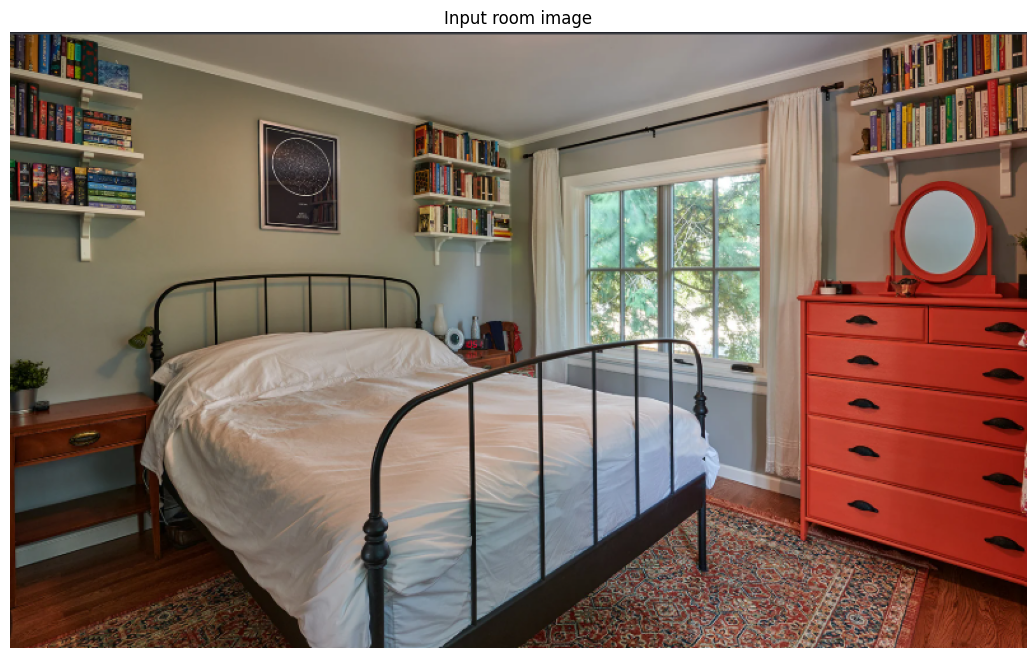

Loaded real test image asset from notebooks/TestRoo.png or another workspace image.


In [12]:
room_image_rgb, image_source, scene_layout = load_room_image()
room_height, room_width = room_image_rgb.shape[:2]
print('Image source:', image_source)
print('Room image shape:', room_image_rgb.shape)

plt.figure(figsize=(14, 8))
plt.imshow(room_image_rgb)
plt.title('Input room image')
plt.axis('off')
plt.show()

if scene_layout:
    print('Synthetic layout keys:', sorted(scene_layout.keys()))
else:
    print('Loaded real test image asset from notebooks/TestRoo.png or another workspace image.')


## Segmentation and Region Modeling

The redesign pipeline begins by separating the room into editable semantic regions. In production, this can come from SAM prompts on the uploaded photo. In the notebook, the same contract is supported by a deterministic fallback so the rest of the workflow remains testable.

Regions we care about most:

1. Wall surfaces for paint and wallpaper changes.
2. Floor surfaces for rug and finish exploration.
3. Furniture and decor objects for style swaps.


Regions available: ['wall', 'floor', 'sofa', 'table', 'lamp', 'plant']
Wall pixels: 32832
Furniture pixels: 68511
Vector layer count: 13
Proxy IoU by region: {
  "table": 0.0,
  "floor": 0.3465,
  "plant": 0.1197,
  "sofa": 0.4673,
  "wall": 0.1516,
  "lamp": 0.2227
}
Proxy segmentation accuracy: 0.218
Region coverage: {
  "wall": 0.0849,
  "floor": 0.1547,
  "sofa": 0.1772,
  "table": 0.1966,
  "lamp": 0.027,
  "plant": 0.0145
}


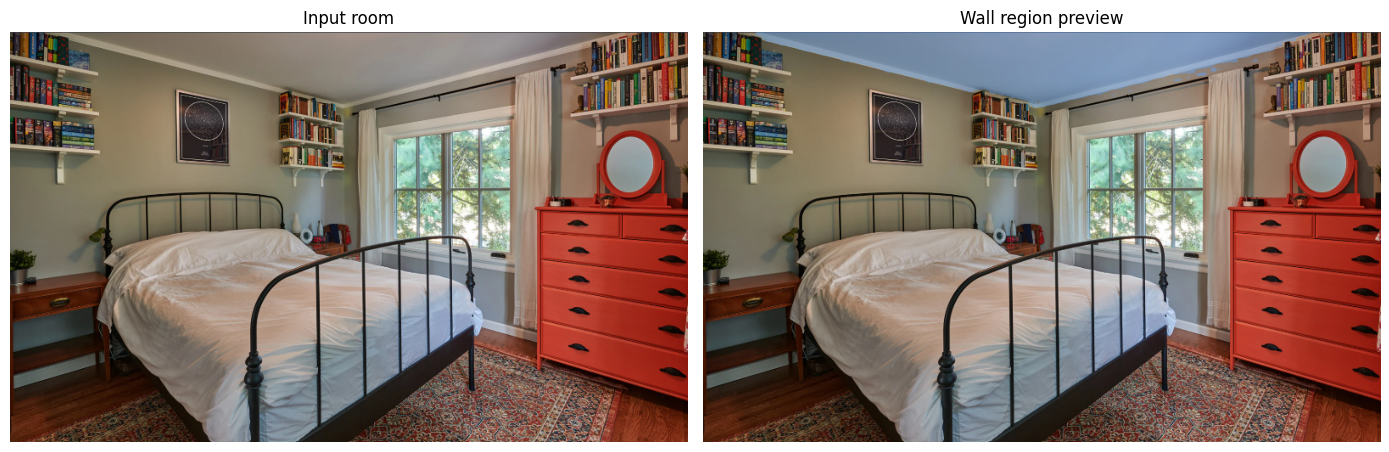

In [13]:
def build_room_masks(image_rgb: np.ndarray, image_source: str, scene_layout: dict[str, Any]) -> dict[str, np.ndarray]:
    height, width = image_rgb.shape[:2]
    masks: dict[str, np.ndarray] = {}

    if image_source == 'synthetic_demo' and scene_layout:
        for name, rectangles in scene_layout.items():
            masks[name] = build_rect_mask((height, width), rectangles)
        return masks

    predictor = try_build_sam_predictor(SAM_CHECKPOINT)
    if predictor is not None:
        predictor.set_image(image_rgb)
        prompt_points = {
            'wall': (int(width * 0.50), int(height * 0.18)),
            'floor': (int(width * 0.50), int(height * 0.82)),
            'sofa': (int(width * 0.35), int(height * 0.72)),
            'table': (int(width * 0.58), int(height * 0.60)),
            'lamp': (int(width * 0.75), int(height * 0.35)),
            'plant': (int(width * 0.84), int(height * 0.62)),
        }
        for name, point in prompt_points.items():
            point_coords = np.array([point], dtype=np.float32)
            point_labels = np.array([1], dtype=np.int32)
            predicted_masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=True,
            )
            best_index = int(np.argmax(scores))
            masks[name] = predicted_masks[best_index].astype(bool)
        return masks

    wall_mask = np.zeros((height, width), dtype=bool)
    floor_mask = np.zeros((height, width), dtype=bool)
    furniture_mask = np.zeros((height, width), dtype=bool)
    wall_mask[: int(height * 0.58), :] = True
    floor_mask[int(height * 0.58) :, :] = True
    furniture_mask[int(height * 0.46) : int(height * 0.88), int(width * 0.10) : int(width * 0.90)] = True
    masks['wall'] = wall_mask
    masks['floor'] = floor_mask
    masks['sofa'] = furniture_mask
    masks['table'] = build_rect_mask((height, width), [(int(width * 0.52), int(height * 0.46), int(width * 0.73), int(height * 0.72))])
    masks['lamp'] = build_rect_mask((height, width), [(int(width * 0.72), int(height * 0.25), int(width * 0.80), int(height * 0.58))])
    masks['plant'] = build_rect_mask((height, width), [(int(width * 0.80), int(height * 0.20), int(width * 0.92), int(height * 0.86))])
    return masks


region_masks = build_room_masks(room_image_rgb, image_source, scene_layout)
reference_masks = build_reference_masks(room_image_rgb.shape[:2], image_source, scene_layout)
mask_names = list(region_masks.keys())
print('Regions available:', mask_names)
print('Wall pixels:', int(region_masks['wall'].sum()) if 'wall' in region_masks else 0)
print('Furniture pixels:', int(region_masks['sofa'].sum()) if 'sofa' in region_masks else 0)

mask_layers = {
    name: mask_to_svg_layers(mask, name, stroke='#ea580c', fill='rgba(255, 255, 255, 0.16)')
    for name, mask in region_masks.items()
}
vector_layer_count = sum(len(layers) for layers in mask_layers.values())
print('Vector layer count:', vector_layer_count)

per_region_iou = {
    name: round(intersection_over_union(region_masks[name], reference_masks[name]), 4)
    for name in region_masks.keys() & reference_masks.keys()
}
proxy_accuracy = round(float(np.mean(list(per_region_iou.values()))) if per_region_iou else 0.0, 4)
coverage = {
    name: round(float(mask.mean()), 4)
    for name, mask in region_masks.items()
}
print('Proxy IoU by region:', json.dumps(per_region_iou, indent=2))
print('Proxy segmentation accuracy:', proxy_accuracy)
print('Region coverage:', json.dumps(coverage, indent=2))

region_preview = overlay_mask(room_image_rgb, region_masks['wall'], (96, 165, 250), alpha=0.42)
show_side_by_side(room_image_rgb, region_preview, 'Input room', 'Wall region preview')


## Wall Colors, Style Transfer, and Palette Suggestions

This section is where the prototype changes the room look.

What it does:

1. Recolors the wall region.
2. Applies preset theme values to furniture masks.
3. Extracts a color palette from the image and recommends wall-color combinations.

What it does not do yet:

1. It does not generate new furniture objects.
2. It does not run a learned style-transfer or diffusion model for furniture replacement.
3. It does not claim general-purpose image editing beyond the room-photo use case.


Room palette:
{
  "kmeansCompactness": 504044366.6894458,
  "regionPixelCount": 386716,
  "swatches": [
    {
      "rank": 0,
      "rgb": [
        127,
        115,
        99
      ],
      "hex": "#7f7363",
      "share": 0.3708
    },
    {
      "rank": 1,
      "rgb": [
        167,
        164,
        156
      ],
      "hex": "#a7a49c",
      "share": 0.2862
    },
    {
      "rank": 2,
      "rgb": [
        53,
        37,
        29
      ],
      "hex": "#35251d",
      "share": 0.2202
    },
    {
      "rank": 3,
      "rgb": [
        161,
        52,
        36
      ],
      "hex": "#a13424",
      "share": 0.1228
    }
  ],
  "roles": {
    "dominant": {
      "weight": 60,
      "swatch": {
        "rank": 0,
        "rgb": [
          127,
          115,
          99
        ],
        "hex": "#7f7363",
        "share": 0.3708
      }
    },
    "secondary": {
      "weight": 30,
      "swatch": {
        "rank": 1,
        "rgb": [
          167,
          164,

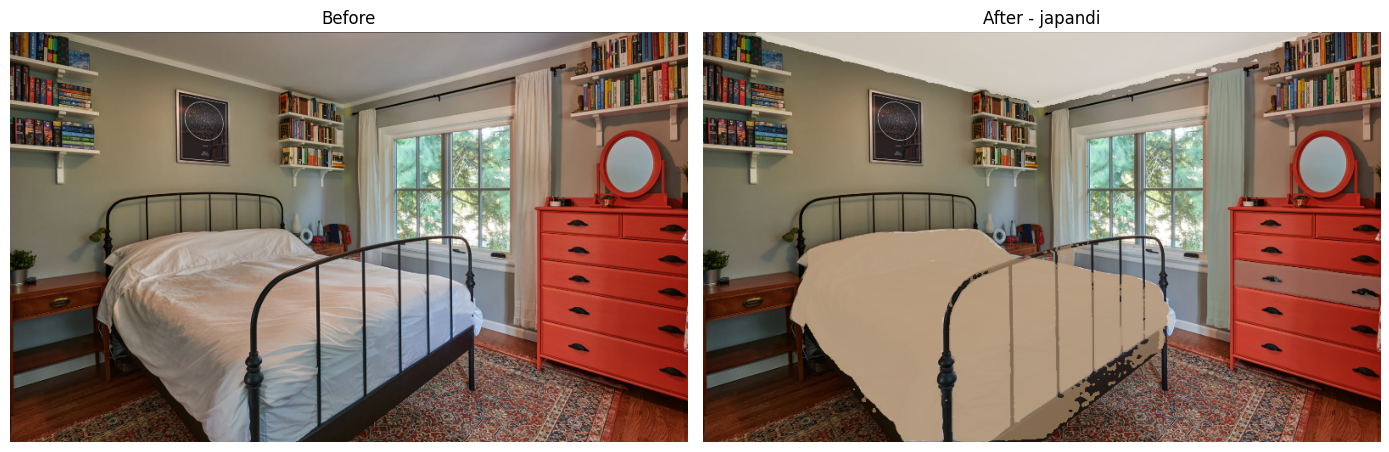

In [14]:
def extract_region_palette(image_rgb: np.ndarray, mask: np.ndarray, k: int = 4) -> dict[str, Any]:
    if mask.dtype != np.bool_:
        mask = mask.astype(bool)

    pixels = image_rgb[mask]
    if pixels.size == 0:
        return {
            'regionPixelCount': 0,
            'swatches': [],
            'roles': {},
        }

    samples = pixels.astype(np.float32)
    unique_samples = np.unique(samples, axis=0)
    cluster_count = max(1, min(k, len(unique_samples)))

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        25,
        1.0,
    )
    compactness, labels, centers = cv2.kmeans(
        samples,
        cluster_count,
        None,
        criteria,
        8,
        cv2.KMEANS_PP_CENTERS,
    )

    counts = np.bincount(labels.flatten(), minlength=cluster_count)
    total = float(counts.sum()) if counts.sum() > 0 else 1.0
    ranked_indices = np.argsort(counts)[::-1]

    swatches: list[dict[str, Any]] = []
    for rank, index in enumerate(ranked_indices):
        rgb = np.clip(np.round(centers[index]), 0, 255).astype(int)
        swatches.append(
            {
                'rank': rank,
                'rgb': [int(rgb[0]), int(rgb[1]), int(rgb[2])],
                'hex': rgb_to_hex(rgb),
                'share': round(float(counts[index]) / total, 4),
            }
        )

    dominant = swatches[0] if swatches else None
    secondary = swatches[1] if len(swatches) > 1 else dominant
    accent = swatches[2] if len(swatches) > 2 else secondary
    return {
        'kmeansCompactness': float(compactness),
        'regionPixelCount': int(len(pixels)),
        'swatches': swatches,
        'roles': {
            'dominant': {'weight': 60, 'swatch': dominant},
            'secondary': {'weight': 30, 'swatch': secondary},
            'accent': {'weight': 10, 'swatch': accent},
        },
    }


def apply_tint(image_rgb: np.ndarray, mask: np.ndarray, target_rgb: list[int] | tuple[int, int, int], strength: float = 0.68) -> np.ndarray:
    result = image_rgb.copy().astype(np.float32)
    target = np.array(target_rgb, dtype=np.float32)
    result[mask] = result[mask] * (1.0 - strength) + target * strength
    return np.clip(result, 0, 255).astype(np.uint8)


def suggest_wall_palettes(room_palette: dict[str, Any]) -> list[dict[str, Any]]:
    swatches = room_palette.get('swatches', [])
    base = swatches[0]['hex'] if len(swatches) > 0 else '#f0e8dc'
    secondary = swatches[1]['hex'] if len(swatches) > 1 else '#d8c7b5'
    accent = swatches[2]['hex'] if len(swatches) > 2 else '#9aa7a1'
    return [
        {'name': 'Warm Minimal', 'wall': base, 'trim': '#ffffff', 'accent': accent},
        {'name': 'Soft Contrast', 'wall': secondary, 'trim': '#f8f3ef', 'accent': base},
        {'name': 'Calm Studio', 'wall': '#e8dfd5', 'trim': '#f4f1ed', 'accent': '#8ea3a0'},
    ]


def apply_style_theme(image_rgb: np.ndarray, masks: dict[str, np.ndarray], theme_name: str) -> np.ndarray:
    theme = STYLE_THEMES[theme_name]
    result = image_rgb.copy()
    if 'wall' in masks:
        result = apply_tint(result, masks['wall'], theme['wall'], strength=0.72)
    if 'sofa' in masks:
        result = apply_tint(result, masks['sofa'], theme['sofa'], strength=0.78)
    if 'table' in masks:
        result = apply_tint(result, masks['table'], theme['wood'], strength=0.70)
    if 'lamp' in masks:
        result = apply_tint(result, masks['lamp'], theme['accent'], strength=0.62)
    if 'plant' in masks:
        result = apply_tint(result, masks['plant'], theme['accent'], strength=0.48)
    return result


full_room_mask = np.ones(room_image_rgb.shape[:2], dtype=bool)
room_palette = extract_region_palette(room_image_rgb, full_room_mask, k=4)
palette_suggestions = suggest_wall_palettes(room_palette)
selected_theme_name = 'japandi'
redesigned_room_rgb = apply_style_theme(room_image_rgb, region_masks, selected_theme_name)

print('Room palette:')
print(json.dumps(room_palette, indent=2))
print('Palette suggestions:')
print(json.dumps(palette_suggestions, indent=2))
print('Selected theme:', selected_theme_name)

show_side_by_side(room_image_rgb, redesigned_room_rgb, 'Before', f'After - {selected_theme_name}')


## Frontend Contract: React, Fabric.js, and Drag-and-Drop

This section describes the browser contract for the prototype, not a finished frontend implementation.

The notebook prepares data that a React + Fabric.js app could consume:

1. Room image metadata.
2. Semantic masks and vector paths.
3. Palette suggestions.
4. A furniture catalog for drag-and-drop UI.
5. A saved JSON redesign payload.

The notebook does not currently include a real React app or a live Fabric.js canvas. Those are represented as downstream consumers of the exported payload.


In [15]:
furniture_catalog = [
    {
        'id': 'sofa-midcentury',
        'label': 'Mid-century sofa',
        'category': 'sofa',
        'style': 'warm modern',
        'previewColor': '#7b6d62',
    },
    {
        'id': 'chair-scandi',
        'label': 'Scandinavian lounge chair',
        'category': 'chair',
        'style': 'airy minimal',
        'previewColor': '#d9d2c7',
    },
    {
        'id': 'table-wood',
        'label': 'Oak coffee table',
        'category': 'table',
        'style': 'natural',
        'previewColor': '#c8a47d',
    },
    {
        'id': 'lamp-arc',
        'label': 'Arc floor lamp',
        'category': 'lamp',
        'style': 'statement',
        'previewColor': '#b88a5a',
    },
]

fabric_layers = [layer for layers in mask_layers.values() for layer in layers]
active_wall_palette = palette_suggestions[0]
redesign_summary = {
    'styleTheme': selected_theme_name,
    'wallPalette': active_wall_palette,
    'catalogItems': furniture_catalog,
    'vectorLayers': fabric_layers,
    'implementationNote': 'This notebook is a prototype: segmentation is partial or fallback-based, palette extraction is real, and furniture replacement is simulated with presets and tinting rather than generative synthesis.',
}


def build_design_payload() -> dict[str, Any]:
    return {
        'source': {
            'imageSource': image_source,
            'imageSize': {'width': int(room_width), 'height': int(room_height)},
        },
        'regions': {
            name: {
                'pixelCount': int(mask.sum()),
                'vectorLayerCount': len(mask_layers.get(name, [])),
                'coverage': round(float(mask.mean()), 4),
                'proxyIoU': round(float(per_region_iou.get(name, 0.0)), 4),
            }
            for name, mask in region_masks.items()
        },
        'metrics': {
            'proxySegmentationAccuracy': proxy_accuracy,
            'perRegionIoU': per_region_iou,
            'coverage': coverage,
            'wallDeltaMeanAbs': round(float(np.mean(np.abs(room_image_rgb[region_masks['wall']].astype(np.float32) - redesigned_room_rgb[region_masks['wall']].astype(np.float32)))), 2) if 'wall' in region_masks and region_masks['wall'].any() else 0.0,
            'furnitureDeltaMeanAbs': round(float(np.mean(np.abs(room_image_rgb[region_masks['sofa']].astype(np.float32) - redesigned_room_rgb[region_masks['sofa']].astype(np.float32)))), 2) if 'sofa' in region_masks and region_masks['sofa'].any() else 0.0,
        },
        'palette': {
            'roomPalette': room_palette,
            'recommendations': palette_suggestions,
            'activeChoice': active_wall_palette,
        },
        'design': {
            'styleTheme': selected_theme_name,
            'beforeAfter': {
                'beforeLabel': 'Original',
                'afterLabel': f'After - {selected_theme_name}',
            },
            'catalog': furniture_catalog,
        },
        'frontendContracts': {
            'fabricLayers': fabric_layers,
            'shareableSummary': redesign_summary,
        },
    }


def save_design_payload(payload: dict[str, Any]) -> tuple[str, Path]:
    payload_text = json.dumps(payload, indent=2, sort_keys=True)
    design_id = hashlib.sha1(payload_text.encode('utf-8')).hexdigest()[:12]
    payload_path = OUTPUT_DIR / f'design_{design_id}.json'
    payload_path.write_text(payload_text, encoding='utf-8')
    return design_id, payload_path


def create_app() -> Flask | None:
    if Flask is None:
        return None

    app = Flask(__name__)

    @app.get('/health')
    def health_check():
        return jsonify({'status': 'ok'})

    @app.post('/api/redesign')
    def redesign_endpoint():
        request_body = request.get_json(force=True) or {}
        return jsonify(
            {
                'status': 'ok',
                'receivedKeys': sorted(request_body.keys()),
                'preview': redesign_summary,
                'metrics': {
                    'proxySegmentationAccuracy': proxy_accuracy,
                    'regionCount': len(region_masks),
                },
            }
        )

    @app.get('/api/share/<design_id>')
    def share_endpoint(design_id: str):
        return jsonify({'designId': design_id, 'message': 'Fetch the saved redesign JSON from storage.'})

    return app


design_payload = build_design_payload()
design_id, design_path = save_design_payload(design_payload)
flask_app = create_app()

print('Design id:', design_id)
print('Saved payload:', design_path)
print('Payload keys:', sorted(design_payload.keys()))
print('Furniture catalog items:', len(furniture_catalog))
print('Proxy segmentation accuracy:', proxy_accuracy)
print('Wall delta mean abs:', design_payload['metrics']['wallDeltaMeanAbs'])
print('Furniture delta mean abs:', design_payload['metrics']['furnitureDeltaMeanAbs'])
print('Implementation note:', redesign_summary['implementationNote'])
print(json.dumps(design_payload, indent=2))


Design id: 7df3e0f38642
Saved payload: s:\AI Interior Design Visualizer\notebooks\outputs\design_7df3e0f38642.json
Payload keys: ['design', 'frontendContracts', 'metrics', 'palette', 'regions', 'source']
Furniture catalog items: 4
Proxy segmentation accuracy: 0.218
Wall delta mean abs: 71.38
Furniture delta mean abs: 25.83
Implementation note: This notebook is a prototype: segmentation is partial or fallback-based, palette extraction is real, and furniture replacement is simulated with presets and tinting rather than generative synthesis.
{
  "source": {
    "imageSource": "test2.png",
    "imageSize": {
      "width": 799,
      "height": 484
    }
  },
  "regions": {
    "wall": {
      "pixelCount": 32832,
      "vectorLayerCount": 1,
      "coverage": 0.0849,
      "proxyIoU": 0.1516
    },
    "floor": {
      "pixelCount": 59832,
      "vectorLayerCount": 4,
      "coverage": 0.1547,
      "proxyIoU": 0.3465
    },
    "sofa": {
      "pixelCount": 68511,
      "vectorLayerCount"